In [2]:
import rasterio

import matplotlib.pyplot as plt
import numpy as np
import glob


# Change sys path to import from parent directory
import sys
sys.path.append('../')

from src import utils
from src import evaluation as eval

In [3]:
all_metrics = {}

# LICS

In [14]:
base_path = '../../data/'

# Load LICS data
incl_bands = [0,1,2,3,4,5,6]
satellite = 'landsat'

# Test data
target_pos = -2

lics_test_file = base_path + 'LICS/test/'
lics_test_paths = glob.glob(lics_test_file + '*.npy')
lics_test_targets = [np.load(file)[:,:,target_pos] for file in lics_test_paths]
lics_test_input = [np.load(file)[:,:,incl_bands] for file in lics_test_paths]

print("Test dimensions:")
print(np.shape(lics_test_targets))
print(np.shape(lics_test_input))


Test dimensions:
(100, 256, 256)
(100, 256, 256, 7)


In [15]:
lics_preds = []

# Get predictions on test set
for test in lics_test_input:

    index = utils.get_index(test,satellite = 'landsat',index="NDWI") #MNDWI 
    pred = utils.get_threshold(index,0)
    lics_preds.append(pred)

metrics, arr = eval.eval_metrics(lics_test_targets,lics_preds)
all_metrics['lics_ndwi'] = metrics
metrics

{'accuracy': np.float64(0.9720526505880406),
 'balanced_accuracy': np.float64(0.9710770360887175),
 'precision': np.float64(0.9942606823487591),
 'recall': np.float64(0.9464444880117212),
 'f1': np.float64(0.9673356554846112),
 'mse': np.float64(0.03772674560546875),
 'fom': np.float64(0.718146291590358)}

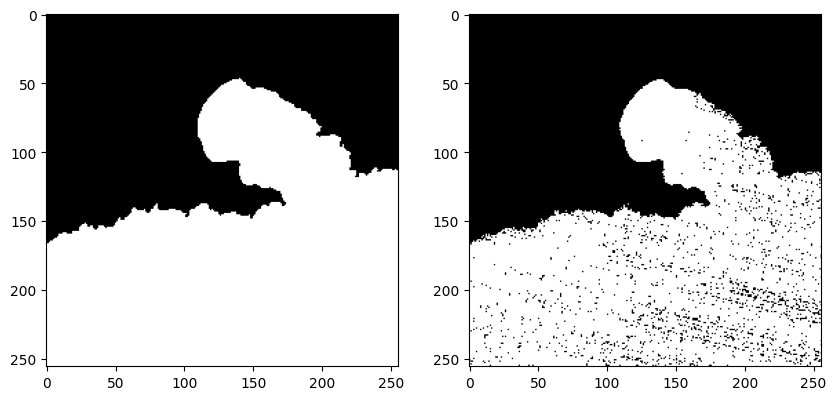

In [16]:
fig, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(lics_test_targets[0],cmap='gray')
ax[1].imshow(lics_preds[0],cmap='gray')

# SWED

In [9]:
# Load LICS data
incl_bands = [0,1,2,3,4,5,6,7,8,9,10,11]
satellite = 'sentinel'

# Test data
target_pos = -1

swed_test_file = base_path + 'SWED/test/'
swed_test_paths = glob.glob(swed_test_file + '*.npy')
swed_test_targets = [np.load(file)[:,:,target_pos] for file in swed_test_paths]
swed_test_input = [np.load(file)[:,:,incl_bands] for file in swed_test_paths]

print("Test dimensions:")
print(np.shape(swed_test_targets))
print(np.shape(swed_test_input))

Test dimensions:
(98, 256, 256)
(98, 256, 256, 12)


In [ ]:
swed_preds = []

# Get predictions on test set
for test in swed_test_input:

    index = utils.get_index(test,satellite = 'sentinel',index="NDWI") #MNDWI 
    pred = utils.get_threshold(index,0)
    swed_preds.append(pred)

metrics, arr = eval.eval_metrics(swed_test_targets,swed_preds)
all_metrics['swed_ndwi'] = metrics
metrics

{'accuracy': np.float64(0.9444486131094423),
 'balanced_accuracy': np.float64(0.924998742340246),
 'precision': np.float64(0.9467071404040175),
 'recall': np.float64(0.9417957586895084),
 'f1': np.float64(0.9368997247878247),
 'mse': np.float64(0.049678413235411355),
 'fom': np.float64(0.6705562929367497)}

# SANet

In [ ]:
train_SANET = np.load('../data/SANet/npyfiles/train/train_groundTruth_arr.npy')
np.shape(train_SANET)

In [14]:
i = 1

14 (256, 256, 1) 0.0 1.0


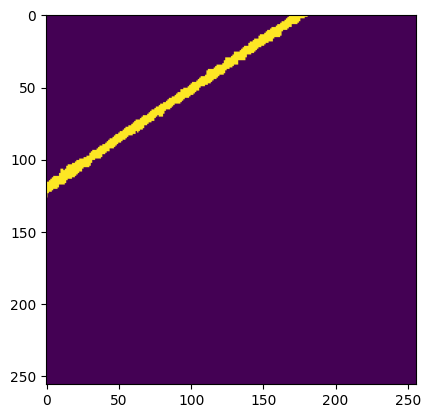

In [27]:
i += 1
train = train_SANET[i]
print(i, np.shape(train), np.min(train), np.max(train))
plt.imshow(train)

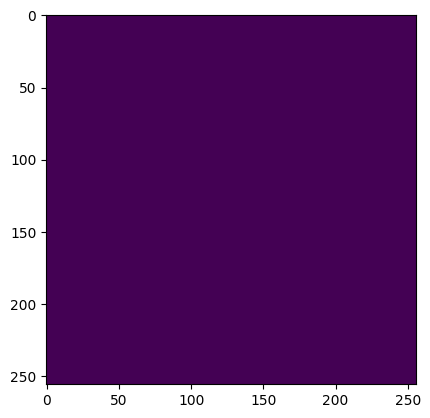

In [ ]:
# using .tif files

In [17]:
def rasterio_to_numpy(path,instype):
    with rasterio.open(path) as src:
        array = src.read()
    
    if instype == 'mask':
        array = np.where(array == 255, 1, 0)
        array = 1 - array #land is 0, water is 1
        array = array.astype(np.uint8)[0]
    elif instype == 'bands':
        array = array.transpose(1,2,0)
    return np.array(array)

In [ ]:
mask_path = "../../data/SANet/croped_images/test/test{}t/test{}t_*.tif"
image_path = "../../data/SANet/croped_images/test/test{}/test{}_*.tif"

mask_paths = []
image_paths = []

for i in range(1,13):
    mask_paths += sorted(glob.glob(mask_path.format(i,i)))
    image_paths += sorted(glob.glob(image_path.format(i,i)))

image_paths = [path for path in image_paths if path not in mask_paths]
#image_paths = sorted(image_paths)

print(f"Number of test masks: {len(mask_paths)}")
print(f"Number of test images: {len(image_paths)}")

print(mask_paths[0])
print(image_paths[0])
print(mask_paths[72])
print(image_paths[72])
print(mask_paths[170])
print(image_paths[170])


sanet_test_targets = [rasterio_to_numpy(path,'mask') for path in mask_paths]
sanet_test_input = [rasterio_to_numpy(path,'bands') for path in image_paths]

print("Test dimensions:")
print(np.shape(sanet_test_targets))
print(np.shape(sanet_test_input))

Number of test masks: 192
Number of test images: 192
../../data/SANet/croped_images/test/test1t/test1t_col0row0.tif
../../data/SANet/croped_images/test/test1/test1_col0row0.tif
../../data/SANet/croped_images/test/test5t/test5t_col2row0.tif
../../data/SANet/croped_images/test/test5/test5_col2row0.tif
../../data/SANet/croped_images/test/test11t/test11t_col2row2.tif
../../data/SANet/croped_images/test/test11/test11_col2row2.tif
Test dimensions:
(192, 256, 256)
(192, 256, 256, 4)


In [95]:
mask_path = "../../data/SANet/croped_images/test/test{}t/testt.tif"
image_path = "../../data/SANet/croped_images/test/test{}/test.tif"

sanet_test_targets = [rasterio_to_numpy(mask_path.format(i),'mask') for i in range(1, 12)]
sanet_test_input = [rasterio_to_numpy(image_path.format(i),'bands') for i in range(1, 12)]

print("Test dimensions:")
print(np.shape(sanet_test_targets))
print(np.shape(sanet_test_input))

Test dimensions:
(11, 1024, 1024)
(11, 1024, 1024, 4)


3
216 902
175 999
112 932
59 882
0 1


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

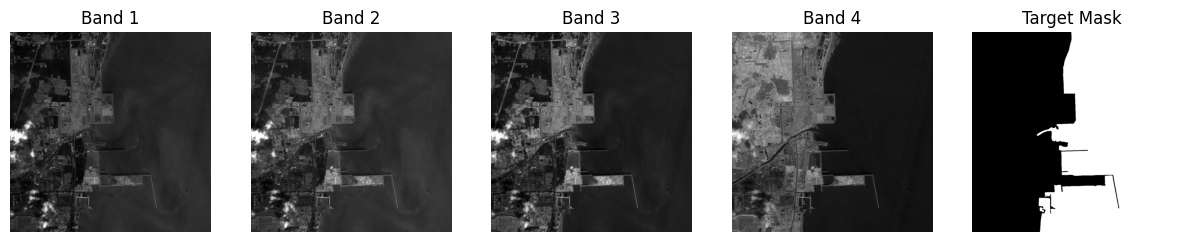

In [118]:
n= np.random.randint(0,len(sanet_test_input))
print(i)
target = sanet_test_targets[n]
input = sanet_test_input[n]

fig, ax = plt.subplots(1,5, figsize=(15,10))

for i in range(0,4):
    band = input[:,:,i]

    print(np.min(band), np.max(band))

    ax[i].imshow(band, cmap='gray')
    ax[i].set_title(f'Band {i+1}')
    ax[i].axis('off')

print(np.min(target), np.max(target))
ax[4].imshow(target, cmap='gray')
ax[4].set_title('Target Mask')
ax[4].axis('off')

In [ ]:
# reimport utils to get updated functions
import importlib
importlib.reload(utils)

sanet_preds = []
sanet_indexes = []

# Get predictions on test set
for test in sanet_test_input:
    index = utils.get_index(test,satellite = 'gaofen1',index="NDWI") #MNDWI 
    sanet_indexes.append(index)
    
    pred = utils.get_threshold(index,0.14)
    sanet_preds.append(pred)

print(len(sanet_preds))

metrics, arr = eval.eval_metrics(sanet_test_targets,sanet_preds)
all_metrics['sanet_ndwi'] = metrics
metrics

11


{'accuracy': np.float64(0.6403891823508523),
 'balanced_accuracy': np.float64(0.6351549426017681),
 'precision': np.float64(0.5835248424402448),
 'recall': np.float64(0.9979431444355378),
 'f1': np.float64(0.7248422703178216),
 'mse': np.float64(0.06716970963911577),
 'fom': np.float64(0.04549990199402694)}

0
0 1


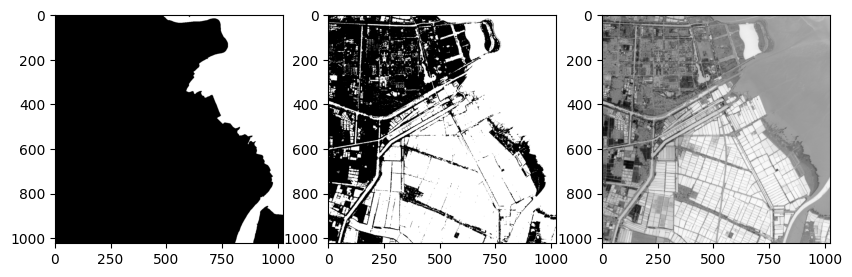

In [134]:
fig, ax = plt.subplots(1,3, figsize=(10,10))
n=0
print(n)
target = sanet_test_targets[n]
print(np.min(target), np.max(target))

ax[0].imshow(sanet_test_targets[n],cmap='gray')
ax[1].imshow(sanet_preds[n],cmap='gray')
ax[2].imshow(sanet_indexes[n],cmap='gray')


215021 833555


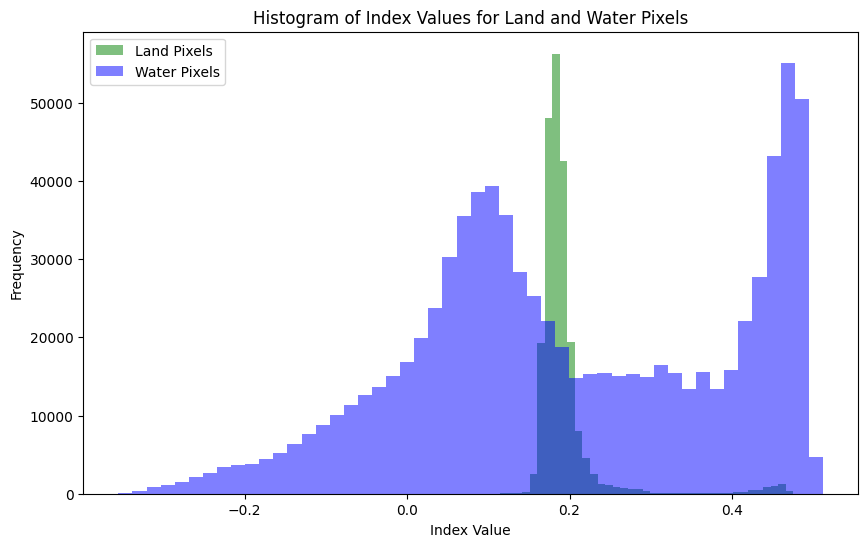

In [122]:
# Plot histogram of index values for land and water pixels
land_pixels = sanet_indexes[n][sanet_test_targets[n] == 1]
water_pixels = sanet_indexes[n][sanet_test_targets[n] == 0]

print(len(land_pixels), len(water_pixels)  )

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(land_pixels.flatten(), bins=50, alpha=0.5, label='Land Pixels', color='green')
ax.hist(water_pixels.flatten(), bins=50, alpha=0.5, label='Water Pixels', color='blue')
ax.set_title('Histogram of Index Values for Land and Water Pixels')
ax.set_xlabel('Index Value')
ax.set_ylabel('Frequency')
ax.legend()

In [ ]:
# using .npy files

In [25]:
def format_mask(mask):
    return 1-mask[0].transpose(2, 0, 1)[0]

In [26]:
image_path = "../../data/SANet/npyfiles/test/test{}/test_image_arr.npy"
mask_path = "../../data/SANet/npyfiles/test/test{}/test_mask_arr.npy"

sanet_test_targets = [format_mask(np.load(mask_path.format(i))) for i in range(1, 12)]
sanet_test_input = [np.load(image_path.format(i))[0] for i in range(1, 12)]

print("Test dimensions:")
print(np.shape(sanet_test_targets))
print(np.shape(sanet_test_input))

Test dimensions:
(11, 1024, 1024)
(11, 1024, 1024, 4)


In [19]:
# scale bands
band_mins = np.array([1.7215686274509805,
                      1.5960784313725491,
                      1.007843137254902,
                      0.7098039215686275], dtype=np.float32)
band_maxs = np.array([3.9215686274509802,
                      3.9607843137254903,
                      3.796078431372549,
                      3.937254901960784], dtype=np.float32)

sanet_test_input = [(img - band_mins) / (band_maxs - band_mins) for img in sanet_test_input]

1.7215686274509805 3.9215686274509802
1.5960784313725491 3.9607843137254903
1.007843137254902 3.796078431372549
0.7098039215686275 3.937254901960784


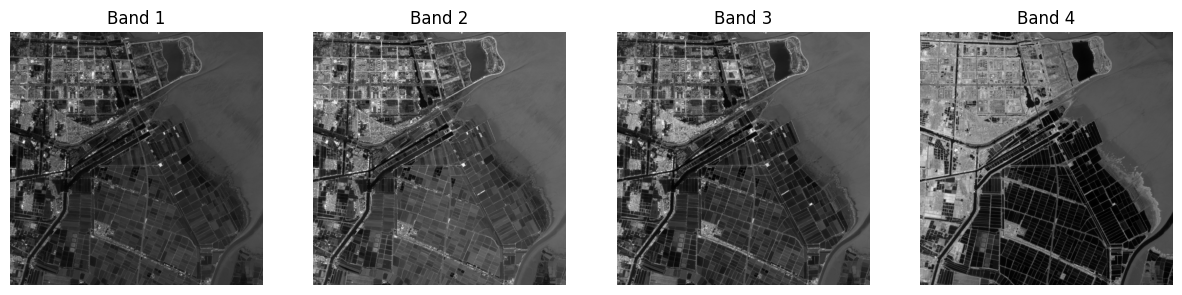

In [ ]:
sanet_test_input_0 = sanet_test_input[0]

fig, ax = plt.subplots(1,4, figsize=(15,10))

for i in range(0,4):
    band = sanet_test_input_0[:,:,i]

    print(np.min(band), np.max(band))

    ax[i].imshow(band, cmap='gray')
    ax[i].set_title(f'Band {i+1}')
    ax[i].axis('off')

In [ ]:
sanet_preds = []

# Get predictions on test set
for test in sanet_test_input:
    index = utils.get_index(test,satellite = 'gaofen1',index="NDWI") #MNDWI 
    pred = utils.get_threshold(index,0.1)
    sanet_preds.append(pred)

metrics, arr = eval.eval_metrics(sanet_test_targets,sanet_preds)
all_metrics['sanet_ndwi'] = metrics
metrics

{'accuracy': np.float64(0.5995777303522284),
 'balanced_accuracy': np.float64(0.5961099354792553),
 'precision': np.float64(0.5549149173047215),
 'recall': np.float64(0.9993709217684781),
 'f1': np.float64(0.7025196331768726),
 'mse': np.float64(0.057371659712357956),
 'fom': np.float64(0.03958736122520426)}

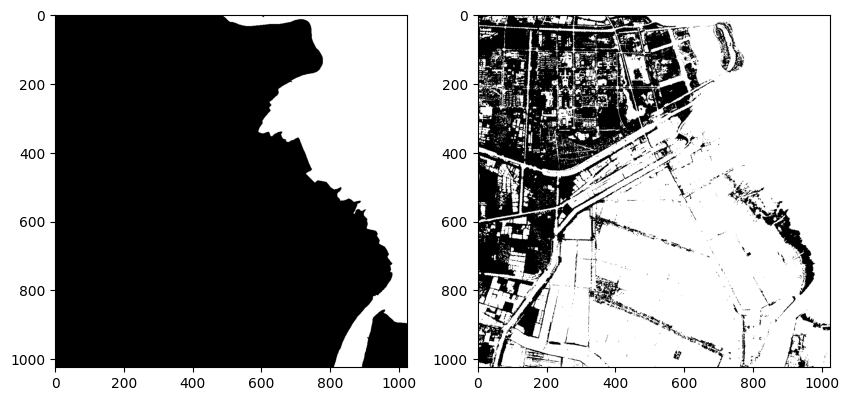

In [29]:
fig, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(sanet_test_targets[0],cmap='gray')
ax[1].imshow(sanet_preds[0],cmap='gray')

# TCUNet

In [21]:
def tcunet_rasterio_to_numpy(path, instype):
    with rasterio.open(path) as src:
        array = src.read()

        if instype == 'bands':
            array = array.transpose(1,2,0)
        elif instype == 'mask':
            array = array[0]

    return np.array(array)

In [22]:
image_path = "../../data/TCUNet/test/images/*.tif"

image_paths = glob.glob(image_path)
mask_paths = [path.replace('images','mndwi') for path in image_paths]

tcunet_test_targets = [tcunet_rasterio_to_numpy(path,'mask') for path in mask_paths]
tcunet_test_input = [tcunet_rasterio_to_numpy(path,'bands') for path in image_paths]

print(len(tcunet_test_targets),len(tcunet_test_input))

/Users/conorosullivan/Documents/git/COASTAL_MONITORING/instantaneous-coastline-comparison/venv/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


215 215


0 255
12 195
12 255
7 255
3 255
4 249
2 252
0 101
8 230


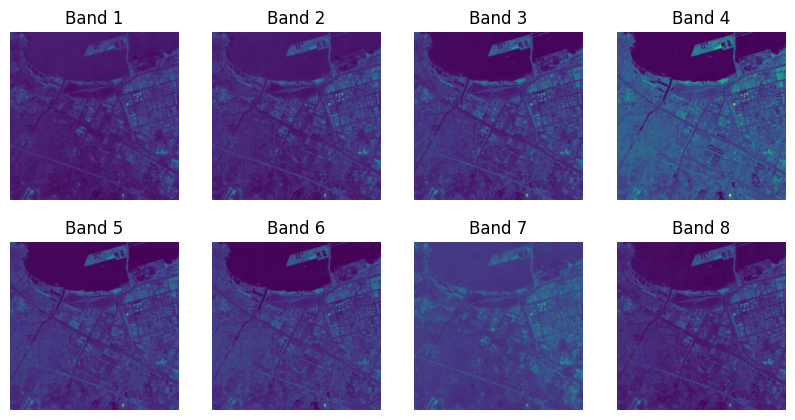

In [25]:
n = 0

target = tcunet_test_targets[n]
print(np.min(target),np.max(target))


fig,ax = plt.subplots(2,4,figsize=(10,5))
ax = ax.flatten()

bands = tcunet_test_input[n]
for i in range(8):

    band = bands[:,:,i]
    print(np.min(band),np.max(band))

    ax[i].imshow(band)
    ax[i].set_title(f'Band {i+1}')
    ax[i].axis('off')

In [30]:
# reimport utils to get updated functions
import importlib
importlib.reload(utils)

tcunet_preds = []
tcunet_indexes = []

# Get predictions on test set
for test in tcunet_test_input:
    index = utils.get_index(test,satellite = 'gaofen6',index="NDWI") #MNDWI 
    tcunet_indexes.append(index)
    
    pred = utils.get_threshold(index,0)
    tcunet_preds.append(pred)

print(len(tcunet_preds))

metrics, arr = eval.eval_metrics(tcunet_test_targets,tcunet_preds)
all_metrics['tcunet_ndwi'] = metrics
metrics

215


/Users/conorosullivan/Documents/git/COASTAL_MONITORING/instantaneous-coastline-comparison/notebooks/../src/evaluation.py:58: RuntimeWarning: invalid value encountered in scalar divide
  balanced_accuracy = 0.5 * (TP_ / (TP_ + FN_) + TN_ / (TN_ + FP_))
/Users/conorosullivan/Documents/git/COASTAL_MONITORING/instantaneous-coastline-comparison/notebooks/../src/evaluation.py:60: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP_ / (TP_ + FN_)
/Users/conorosullivan/Documents/git/COASTAL_MONITORING/instantaneous-coastline-comparison/notebooks/../src/evaluation.py:59: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP_ / (TP_ + FP_)


{'accuracy': np.float64(0.9900606446959936),
 'balanced_accuracy': np.float64(nan),
 'precision': np.float64(nan),
 'recall': np.float64(nan),
 'f1': np.float64(nan),
 'mse': np.float64(0.020610259300054504),
 'fom': np.float64(0.7721188091164151)}

0
0 255


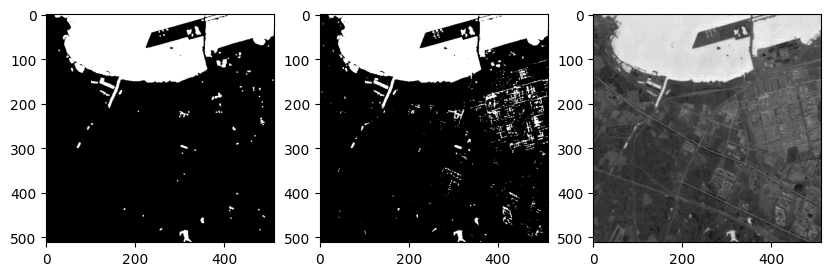

In [31]:
fig, ax = plt.subplots(1,3, figsize=(10,10))
n=0
print(n)
target = tcunet_test_targets[n]
print(np.min(target), np.max(target))

ax[0].imshow(tcunet_test_targets[n],cmap='gray')
ax[1].imshow(tcunet_preds[n],cmap='gray')
ax[2].imshow(tcunet_indexes[n],cmap='gray')

In [ ]:
for 